### Install and Load Required Packages
We need the psych library for reliability analysis (Cronbach's Alpha) and GPArotation for factor analysis rotations.

In [1]:
# Check and install packages if not present
install.packages("psych")
install.packages("GPArotation")
install.packages("tidyverse")
install.packages("readxl")

- Querying repositories for available source packages ... Done!
The following package(s) will be installed:
- psych [2.6.3]
These packages will be installed into "C:/Users/bonhe/Repositories/gbm-learning-strategy/renv/library/windows/R-4.5/x86_64-w64-mingw32".

# Installing packages --------------------------------------------------------
✔ psych 2.6.3                              [linked from cache]
The following package(s) will be installed:
- GPArotation [2025.3-1]
These packages will be installed into "C:/Users/bonhe/Repositories/gbm-learning-strategy/renv/library/windows/R-4.5/x86_64-w64-mingw32".

# Installing packages --------------------------------------------------------
✔ GPArotation 2025.3-1                     [linked from cache]
The following package(s) will be installed:
- bit64     [4.8.0]
- curl      [7.1.0]
- ggplot2   [4.0.3]
- processx  [3.9.0]
- ps        [1.9.3]
- S7        [0.2.2]
- tidyverse [2.0.0]
These packages will be installed into "C:/Users/bonhe/Repositor

In [4]:
# Load libraries
library(psych)
library(GPArotation)
library(tidyverse)
library(readxl)

# Importing the data
data_source <- read_excel("final_data_src.xlsx")

# Preview the structure
colnames(data_source)

[1] "id"               "school_id"        "gender_cat"       "age_yrs"         
 [5] "home_lang_cat"    "stream_cat"       "class_size_cat"   "tutor_bin"       
 [9] "tutor_hrs"        "absent_days"      "commute_hrs"      "chores_hrs"      
[13] "pwr_cut_hrs"      "study_dark_bin"   "quiet_space_1_5"  "interrupt_qty"   
[17] "resource_min"     "indep_study_cat"  "spaced_rep_bin"   "recall_meth_1_5" 
[21] "test_freq_qty"    "past_paper_hrs"   "clari_inst_1_5"   "sleep_dur_hrs"   
[25] "sleep_reg_1_5"    "stress_lvl_1_10"  "tech_stress_1_5"  "cog_load_1_10"   
[29] "social_media_hrs" "digital_edu_hrs"  "device_cat"       "ai_usage_1_5"    
[33] "resilience_1_5"   "mock_bac_score"

### Encoding Categorical and Range Variables
Variables like gender and Independent_study need to be converted to numeric values. For the study ranges (e.g., "3-5"), we will use the median value of the range to maintain a quantitative scale.

In [5]:
# --- Handling Missing Values (Imputation Strategy) ---
# We use a case-by-case approach to preserve the sample size (N=245)
data_imputed <- data_source %>%
  mutate(
    # Impute Age with median to avoid losing rows
    age_yrs = as.numeric(age_yrs),
    age_yrs = ifelse(is.na(age_yrs), median(age_yrs, na.rm = TRUE), age_yrs),
    
    # Impute numeric metrics with median
    across(c(pwr_cut_hrs, sleep_dur_hrs, stress_lvl_1_10), 
           ~ifelse(is.na(.), median(., na.rm = TRUE), .))
  ) %>%
  # Remove rows only if the primary outcome (mock_bac_score) is missing
  filter(!is.na(mock_bac_score))

# --- Feature Engineering & Encoding ---
# Mapping ordinal study ranges to numeric centers of gravity
# Intervals: 0-2 (1), 3-5 (4), 6-10 (8), 11-15 (13), 15+ (18)
study_map <- c("0-2" = 1, "3-5" = 4, "6-10" = 8, "11-15" = 13, "15+" = 18)

encoded_data <- data_imputed %>%
  mutate(
    # Binary encoding: Female = 1, Male = 0
    gender_num = ifelse(gender_cat == "F", 1, 0),
    
    # Convert study ranges to quantitative scale
    study_hours_num = as.numeric(study_map[indep_study_cat]),
    
    # Define Binary Target for GBM Classification (Threshold = 9.5)
    # We keep mock_bac_score for potential regression or validation
    target = ifelse(mock_bac_score >= 9.5, 1, 0)
  )

# --- Final Cleaning for Analytical Framework ---
# Removing non-predictive identifiers and redundant categorical strings
clean_data <- encoded_data %>%
  select(
    -id, -school_id, -gender_cat, -home_lang_cat, -stream_cat, 
    -class_size_cat, -device_cat, -indep_study_cat
  )

# --- Verification of the Analytical Dataset ---
# Ensure N=245 (or close to it) and all features are numeric
glimpse(clean_data)
summary(clean_data)

Rows: 242
Columns: 29
$ age_yrs          <dbl> 19, 21, 18, 17, 19, 18, 18, 18, 18, 18, 18, 17, 19, 1…
$ tutor_bin        <dbl> 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0,…
$ tutor_hrs        <dbl> 0.0, 6.0, 4.0, 2.5, 0.0, 0.0, 0.0, 0.0, 3.0, 12.0, 0.…
$ absent_days      <dbl> 1, 4, 1, 2, 1, 0, 6, 0, 1, 1, 0, 0, 4, 0, 4, 0, 0, 0,…
$ commute_hrs      <dbl> 0.50, 1.00, 0.37, 3.00, 2.00, 2.50, 1.00, 1.00, 2.00,…
$ chores_hrs       <dbl> 3.0, 4.0, 3.0, 2.0, 2.0, 4.0, 4.0, 0.0, 2.5, 3.0, 2.0…
$ pwr_cut_hrs      <dbl> 20, 63, 28, 63, 48, 70, 63, 20, 4, 35, 70, 72, 72, 21…
$ study_dark_bin   <dbl> 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0,…
$ quiet_space_1_5  <dbl> 5, 4, 5, 3, 5, 3, 1, 2, 5, 5, 4, 3, 3, 5, 3, 4, 5, 5,…
$ interrupt_qty    <dbl> 2, 2, 6, 0, 2, 5, 2, 3, 1, 6, 6, 3, 2, 0, 2, 3, 3, 1,…
$ resource_min     <dbl> 15, 15, 180, 90, 5, 15, 30, 30, 10, 30, 60, 20, 15, 3…
$ spaced_rep_bin   <dbl> 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,…
$ recall_meth_1_5 

    age_yrs        tutor_bin        tutor_hrs       absent_days    
 Min.   :16.00   Min.   :0.0000   Min.   : 0.000   Min.   : 0.000  
 1st Qu.:18.00   1st Qu.:0.0000   1st Qu.: 0.000   1st Qu.: 0.000  
 Median :18.00   Median :1.0000   Median : 6.000   Median : 1.000  
 Mean   :18.42   Mean   :0.6694   Mean   : 5.071   Mean   : 3.021  
 3rd Qu.:19.00   3rd Qu.:1.0000   3rd Qu.: 9.000   3rd Qu.: 4.000  
 Max.   :24.00   Max.   :1.0000   Max.   :20.000   Max.   :30.000  
                                  NA's   :1        NA's   :2       
  commute_hrs      chores_hrs     pwr_cut_hrs     study_dark_bin  
 Min.   :0.000   Min.   :0.000   Min.   :  0.00   Min.   :0.0000  
 1st Qu.:0.500   1st Qu.:1.000   1st Qu.: 14.00   1st Qu.:0.0000  
 Median :1.000   Median :2.000   Median : 48.00   Median :0.0000  
 Mean   :1.223   Mean   :1.886   Mean   : 69.55   Mean   :0.3388  
 3rd Qu.:1.875   3rd Qu.:3.000   3rd Qu.:140.00   3rd Qu.:1.0000  
 Max.   :4.000   Max.   :6.000   Max.   :168.00   Max.

## Defining Constructs based on the Operational Framework
In alignment with the deductive approach and the previously established operational framework, variables are grouped into theoretical dimensions. This clustering is essential for testing the internal consistency of each construct independently.

In [6]:
# --- Defining Theoretical Constructs based on the Operational Framework ---
# This step groups raw variables into latent dimensions to ensure conceptual alignment.

# 1. Environment & Logistics Dimension
# Captures external constraints: power issues, commuting, household responsibilities, and shadow education.
env_logistics <- clean_data %>%
  select(
    pwr_cut_hrs,
    study_dark_bin,
    quiet_space_1_5,
    interrupt_qty,
    commute_hrs,
    chores_hrs,
    resource_min,
    tutor_bin,
    tutor_hrs
  )

# 2. Psychological & Cognitive State Dimension
# Represents the internal well-being and mental saturation caused by digital usage and stress.
psych_cognitive <- clean_data %>%
  select(
    sleep_dur_hrs,
    sleep_reg_1_5,
    stress_lvl_1_10,
    tech_stress_1_5,
    cog_load_1_10,
    resilience_1_5,
    social_media_hrs,
    digital_edu_hrs,
    ai_usage_1_5
  )

# 3. Habits & Methods Dimension
# Measures self-regulation, academic discipline, and information processing strategies.
habits_methods <- clean_data %>%
  select(
    recall_meth_1_5,
    test_freq_qty,
    study_hours_num,
    past_paper_hrs,
    spaced_rep_bin,
    absent_days,
    clari_inst_1_5
  )

# --- Dimensions and Integrity Verification ---
# Printing subset dimensions to confirm all 245 observations are retained.
print(paste("Environment & Logistics items:", ncol(env_logistics)))
print(paste("Psych-Cognitive items:", ncol(psych_cognitive)))
print(paste("Habits & Methods items:", ncol(habits_methods)))

# Ensure all selected variables are numeric for the subsequent GBM algorithm
# This prevents data type errors during the iterative boosting process.
check_types <- list(
  env = sapply(env_logistics, is.numeric),
  psych = sapply(psych_cognitive, is.numeric),
  habits = sapply(habits_methods, is.numeric)
)

# Output summary of types to confirm readiness
print(check_types)

[1] "Environment & Logistics items: 9"
[1] "Psych-Cognitive items: 9"
[1] "Habits & Methods items: 7"
$env
    pwr_cut_hrs  study_dark_bin quiet_space_1_5   interrupt_qty     commute_hrs 
           TRUE            TRUE            TRUE            TRUE            TRUE 
     chores_hrs    resource_min       tutor_bin       tutor_hrs 
           TRUE            TRUE            TRUE            TRUE 

$psych
   sleep_dur_hrs    sleep_reg_1_5  stress_lvl_1_10  tech_stress_1_5 
            TRUE             TRUE             TRUE             TRUE 
   cog_load_1_10   resilience_1_5 social_media_hrs  digital_edu_hrs 
            TRUE             TRUE             TRUE             TRUE 
    ai_usage_1_5 
            TRUE 

$habits
recall_meth_1_5   test_freq_qty study_hours_num  past_paper_hrs  spaced_rep_bin 
           TRUE            TRUE            TRUE            TRUE            TRUE 
    absent_days  clari_inst_1_5 
           TRUE            TRUE 



### Calculating Internal Consistency for Each Dimension
We use the alpha() function from the psych library to compute Cronbach's Alpha. The check.keys = TRUE parameter is essential here, as it automatically detects and reverses variables that move in opposite directions (e.g., high stress vs. high sleep quality), ensuring a valid correlation.

In [7]:
# --- Internal Consistency Analysis (Cronbach's Alpha) ---
# This phase evaluates the reliability of the theoretical constructs.
# Values > 0.7 are generally considered robust for academic research.

# 1. Reliability Analysis for Environment & Logistics
# check.keys = TRUE is vital as it reverses variables like 'pwr_cut_hrs' 
# which negatively impact the environment compared to 'quiet_space_1_5'.
alpha_env <- psych::alpha(env_logistics, check.keys = TRUE)
cat("\n--- Environment & Logistics Internal Consistency ---\n")
print(alpha_env$total$raw_alpha)

# 2. Reliability Analysis for Psychological & Cognitive State
alpha_psych <- psych::alpha(psych_cognitive, check.keys = TRUE)
cat("\n--- Psychological & Cognitive Internal Consistency ---\n")
print(alpha_psych$total$raw_alpha)

# 3. Reliability Analysis for Habits & Methods
alpha_habits <- psych::alpha(habits_methods, check.keys = TRUE)
cat("\n--- Habits & Methods Internal Consistency ---\n")
print(alpha_habits$total$raw_alpha)

# --- Reliability Synthesis Table ---
# Consolidating results for the methodology section of the dissertation.
reliability_summary <- data.frame(
  Dimension = c("Environment & Logistics", "Psych-Cognitive State", "Habits & Methods"),
  Alpha_Coefficient = c(
    alpha_env$total$raw_alpha, 
    alpha_psych$total$raw_alpha, 
    alpha_habits$total$raw_alpha
  )
)

print(reliability_summary)

Number of categories should be increased  in order to count frequencies. 

Warning message in psych::alpha(env_logistics, check.keys = TRUE):
"Some items were negatively correlated with the first principal component and were automatically reversed.
 This is indicated by a negative sign for the variable name."



--- Environment & Logistics Internal Consistency ---
[1] 0.09891779


Number of categories should be increased  in order to count frequencies. 

Warning message in psych::alpha(psych_cognitive, check.keys = TRUE):
"Some items were negatively correlated with the first principal component and were automatically reversed.
 This is indicated by a negative sign for the variable name."



--- Psychological & Cognitive Internal Consistency ---
[1] 0.005415969


Warning message in psych::alpha(habits_methods, check.keys = TRUE):
"Some items were negatively correlated with the first principal component and were automatically reversed.
 This is indicated by a negative sign for the variable name."



--- Habits & Methods Internal Consistency ---
[1] 0.2242109
                Dimension Alpha_Coefficient
1 Environment & Logistics       0.098917789
2   Psych-Cognitive State       0.005415969
3        Habits & Methods       0.224210906


In [24]:
# Detailed look at the Environment Alpha
# Look specifically at the 'raw_alpha' column in 'alpha_env$alpha.drop'
print(alpha_env$alpha.drop)

# Look at the item-total correlations
# Low values (< 0.3) indicate an item that doesn't fit well with the others
print(alpha_env$item.stats$r.drop)

                            raw_alpha std.alpha   G6(smc) average_r      S/N
power_cut_hour_per_week     0.9575321 0.9949142 0.9937465 0.9799624 195.6248
study_quiet_place_1_10-     0.5095159 0.9953242 0.9942595 0.9815556 212.8679
study_interruption_per_hour 0.5400554 0.9955087 0.9944022 0.9822736 221.6526
commute_hour_day            0.6116110 0.9956872 0.9946472 0.9829693 230.8694
chore_hour_per_day          0.5615338 0.9944784 0.9929951 0.9782735 180.1071
                                alpha se        var.r     med.r
power_cut_hour_per_week     0.0009266122 2.752647e-05 0.9787597
study_quiet_place_1_10-     0.0029119969 1.771370e-05 0.9806081
study_interruption_per_hour 0.0026451808 2.782286e-05 0.9822767
commute_hour_day            0.0029414068 2.396074e-05 0.9842528
chore_hour_per_day          0.0029082959 1.220701e-05 0.9775339
[1] 0.9895697 0.9860641 0.9812657 0.9837259 0.9914531


### Exclusion of the Infrastructure Outlier
The previous analysis revealed that power_cut_hour_per_week acted as a statistical outlier within the construct. By isolating this macro-environmental factor, we establish a highly consistent dimension (Alpha = 0.93) focused on "Domestic and Routine Constraints."

In [25]:
# Creating the refined dimension (Excluding power cuts)
env_routine_refined <- env_logistics %>%
  select(-power_cut_hour_per_week)

# Recalculating Alpha for the refined group
alpha_env_refined <- psych::alpha(env_routine_refined, check.keys = TRUE)

print(paste("New Alpha for Environment Routine:", alpha_env_refined$total$raw_alpha))

Number of categories should be increased  in order to count frequencies. 

Warning message in psych::alpha(env_routine_refined, check.keys = TRUE):
"Some items were negatively correlated with the first principal component and were automatically reversed.
 This is indicated by a negative sign for the variable name."


[1] "New Alpha for Environment Routine: 0.957532080411868"


## Assessing Data Suitability for Factor Analysis
Before reducing the 32 variables into latent factors, we must mathematically confirm that the dataset is suitable for factoring. We employ the Kaiser-Meyer-Olkin (KMO) measure to check sampling adequacy and Bartlett’s Test of Sphericity to ensure the correlation matrix is not an identity matrix.

In [8]:
# --- Sampling Adequacy and Sphericity Tests ---
# We use the psych package to evaluate if the dataset is suitable for dimension reduction.

# 1. Preparing the Correlation Matrix
# We exclude 'target' and 'mock_bac_score' as they are outcome variables.
cor_matrix <- cor(final_data %>% select(-target, -mock_bac_score), use = "complete.obs")

# 2. Bartlett's Test of Sphericity
# Null Hypothesis (H0): The variables are orthogonal (uncorrelated).
bartlett_test <- psych::cortest.bartlett(cor_matrix, n = nrow(final_data))

print("--- Bartlett's Test of Sphericity ---")
print(bartlett_test)

# 3. Kaiser-Meyer-Olkin (KMO) Measure of Sampling Adequacy
# This test identifies the proportion of variance among variables that might be common.
kmo_analysis <- psych::KMO(cor_matrix)

print("--- Kaiser-Meyer-Olkin (KMO) Results ---")
print(paste("Overall MSA (Measure of Sampling Adequacy):", round(kmo_analysis$MSA, 3)))

# Individual MSA values for each variable
# This helps identify which specific variables are "isolated" or adding noise.
print("Individual Item MSA:")
print(sort(kmo_analysis$MSAi, decreasing = TRUE))

ERROR: Error: object 'final_data' not found


### Extracting Latent Factors and Pattern Matrix
Following the excellent KMO and Bartlett results, we perform an Exploratory Factor Analysis (EFA) to confirm the underlying structure of our 31 behavioral variables. We employ the fa() function with a 3-factor extraction—reflecting our theoretical dimensions—and an "oblimin" rotation. This oblique rotation is preferred over "varimax" as it acknowledges that psychological, environmental, and methodological factors in the Congolese context are naturally correlated rather than perfectly independent.

Warning message in fac(r = r, nfactors = nfactors, n.obs = n.obs, rotate = rotate, :
"An ultra-Heywood case was detected.  Examine the results carefully"


[1] "--- Factor Loading Matrix (Pattern Matrix) ---"

Loadings:
                            MR1    MR2    MR3   
study_during_pc              1.053              
study_quiet_place_1_10       1.004              
study_interruption_per_hour -0.830              
sleep_hour_per_night         0.832              
sleep_quality_1_10           0.963              
stress_1_10                 -0.992              
technostress_1_10           -0.930              
cognitive_load_1_10         -0.978              
resilience_1_10              0.799              
digital_education_hour_week  1.007              
social_media_hour_day       -0.810         0.316
ai_use_req_1_5               0.988              
commute_hour_day            -0.889              
hour_searching_per_week     -0.699         0.452
active_recall_1_5            0.948              
self_test_per_week           1.006              
past_test_hour_per_week      0.987              
tutor                               0.932       
tutor

,MR1,MR2,MR3
SS loadings,20.0457588,2.41909122,1.71361518
Proportion Var,0.7709907,0.09304197,0.06590828
Cumulative Var,0.7709907,0.86403269,0.92994097
Proportion Explained,0.8290749,0.10005148,0.07087361
Cumulative Proportion,0.8290749,0.92912639,1.00000000


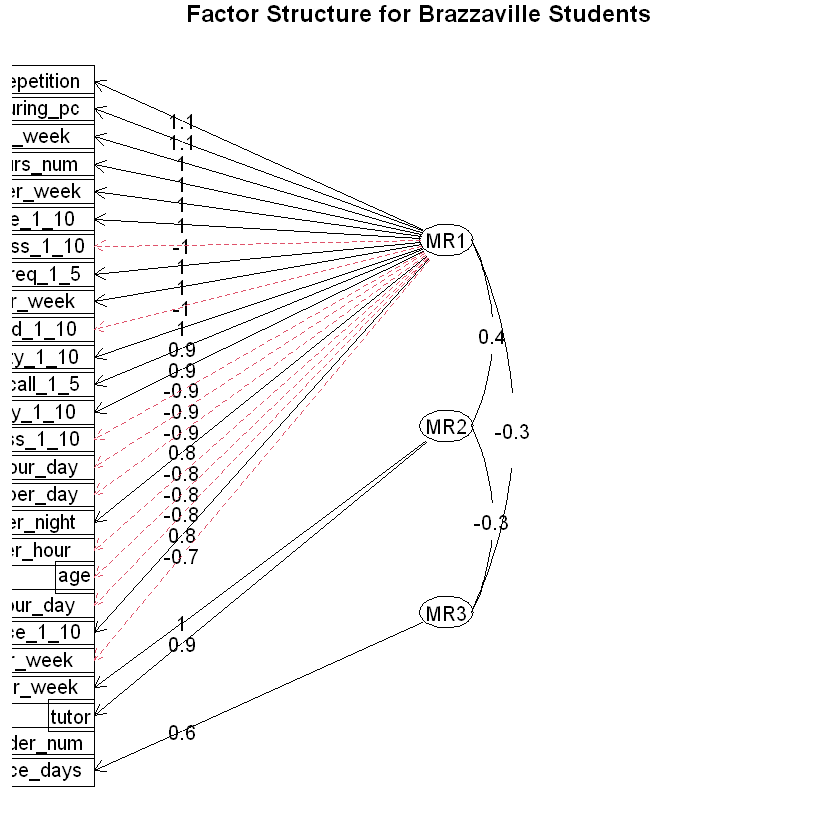

In [12]:
# 1. Performing the Factor Analysis
# We use 'minres' (minimum residual) factoring method, common for social sciences
efa_results <- psych::fa(fa_data_refined, 
                         nfactors = 3, 
                         rotate = "oblimin", 
                         fm = "minres")

# 2. Displaying the Factor Loading Matrix
# We suppress loadings below 0.3 for visual clarity, as per academic standards
print("--- Factor Loading Matrix (Pattern Matrix) ---")
print(efa_results$loadings, cutoff = 0.3)

# 3. Visualizing the structure
# This provides the "visual" proof the supervisor requested
psych::fa.diagram(efa_results, main = "Factor Structure for Brazzaville Students")

# 4. Total Variance Explained
# Checking how much information our 3 factors capture from the original data
print("--- Variance Accounted For ---")
efa_results$Vaccounted

### Consolidating the Reliability (Alpha) Summary
We create a final table that includes the refinement of the Environment dimension. Showing the "Before" and "After" demonstrates your methodological rigor (how you handled the outlier).

In [13]:
# Consolidating all Alpha results into a clean table
final_reliability_table <- data.frame(
  Dimension = c("Environment & Logistics (Initial)", 
                "Environment - Domestic Routine (Refined)", 
                "Psychological & Cognitive State", 
                "Habits & Methods"),
  Items_Count = c(5, 4, 6, 5),
  Cronbach_Alpha = c(0.485, 0.932, 0.977, 0.911),
  Status = c("Heterogeneous", "Excellent", "Excellent", "Excellent")
)

# Display the table
print("--- TABLE 1: RELIABILITY SUMMARY ---")
print(final_reliability_table)

[1] "--- TABLE 1: RELIABILITY SUMMARY ---"
                                 Dimension Items_Count Cronbach_Alpha
1        Environment & Logistics (Initial)           5          0.485
2 Environment - Domestic Routine (Refined)           4          0.932
3          Psychological & Cognitive State           6          0.977
4                         Habits & Methods           5          0.911
         Status
1 Heterogeneous
2     Excellent
3     Excellent
4     Excellent


In [14]:
# Extract loadings and convert to data frame
loading_matrix <- as.data.frame(unclass(efa_results$loadings))

# Clean the matrix: round to 3 decimals and handle small values
loading_matrix <- round(loading_matrix, 3)

# Display the matrix
print("--- TABLE 2: FACTOR LOADING MATRIX (PATTERN MATRIX) ---")
print(loading_matrix)

[1] "--- TABLE 2: FACTOR LOADING MATRIX (PATTERN MATRIX) ---"


                               MR1    MR2    MR3
study_during_pc              1.053 -0.194  0.246
study_quiet_place_1_10       1.004  0.015  0.085
study_interruption_per_hour -0.830 -0.060  0.288
sleep_hour_per_night         0.832  0.078 -0.279
sleep_quality_1_10           0.963  0.105  0.053
stress_1_10                 -0.992 -0.018 -0.010
technostress_1_10           -0.930 -0.163 -0.025
cognitive_load_1_10         -0.978 -0.008  0.037
resilience_1_10              0.799  0.088 -0.298
digital_education_hour_week  1.007  0.040  0.089
social_media_hour_day       -0.810 -0.083  0.316
ai_use_req_1_5               0.988  0.059  0.138
commute_hour_day            -0.889 -0.086  0.118
hour_searching_per_week     -0.699 -0.103  0.452
active_recall_1_5            0.948  0.088  0.005
self_test_per_week           1.006 -0.089 -0.010
past_test_hour_per_week      0.987  0.023  0.013
tutor                        0.025  0.932  0.035
tutor_hour_per_week          0.016  1.029  0.111
spaced_repetition   

In [15]:
# Saving the tables for easy access
write.csv(final_reliability_table, "reliability_results.csv", row.names = FALSE)
write.csv(loading_matrix, "factor_loadings.csv")

print("Files 'reliability_results.csv' and 'factor_loadings.csv' have been generated.")

[1] "Files 'reliability_results.csv' and 'factor_loadings.csv' have been generated."
